<a href="https://colab.research.google.com/github/Oluwasemilore00/Data-Science/blob/main/Practice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("world_population.csv")

In [ ]:
df = df.head(50)
df

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,4.112877e+07,3.897223e+07,3.375350e+07,2.818967e+07,1.954298e+07,1.069480e+07,12486631.0,10752971.0,652230.0,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2.842321e+06,2.866849e+06,2.882481e+06,2.913399e+06,3.182021e+06,3.295066e+06,2941651.0,2324731.0,28748.0,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,4.490322e+07,4.345167e+07,3.954315e+07,3.585634e+07,3.077462e+07,2.551807e+07,18739378.0,13795915.0,2381741.0,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,4.427300e+04,4.618900e+04,5.136800e+04,5.484900e+04,5.823000e+04,4.781800e+04,32886.0,27075.0,199.0,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,7.982400e+04,7.770000e+04,7.174600e+04,7.151900e+04,6.609700e+04,5.356900e+04,35611.0,19860.0,468.0,170.5641,1.0100,0.00
5,42,AGO,Angola,Luanda,Africa,3.558899e+07,3.342848e+07,2.812772e+07,2.336418e+07,1.639406e+07,1.182864e+07,8330047.0,6029700.0,1246700.0,28.5466,1.0315,0.45
6,224,AIA,Anguilla,The Valley,North America,1.585700e+04,1.558500e+04,1.452500e+04,1.317200e+04,1.104700e+04,8.316000e+03,6560.0,6283.0,91.0,174.2527,1.0066,0.00
7,201,ATG,Antigua and Barbuda,Saint John’s,North America,9.376300e+04,9.266400e+04,8.994100e+04,8.569500e+04,7.505500e+04,6.332800e+04,64888.0,64516.0,442.0,212.1335,1.0058,0.00
8,33,ARG,Argentina,Buenos Aires,South America,4.551032e+07,4.503603e+07,4.325706e+07,4.110012e+07,3.707077e+07,3.263766e+07,28024803.0,23842803.0,2780400.0,16.3683,1.0052,0.57
9,140,ARM,Armenia,Yerevan,Asia,2.780469e+06,2.805608e+06,2.878595e+06,2.946293e+06,3.168523e+06,3.556539e+06,3135123.0,2534377.0,29743.0,93.4831,0.9962,0.03


In [ ]:
df.isnull().sum()

,0
Rank,0
CCA3,0
Country,0
Capital,0
Continent,0
2022 Population,0
2020 Population,1
2015 Population,0
2010 Population,1
2000 Population,0


* It is observed that there are 2 null values from the year 2010 and 2020 respectively and because they are numbers they can be replaced with (Zero)

1. To see whether there is an increase or decrease in the World population over the years.
2. To evaluate the country with the highest or most significant growth rate.
3. What is the average population of each continent?

In [ ]:
df = df.fillna(0)
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Rank,0
CCA3,0
Country,0
Capital,0
Continent,0
2022 Population,0
2020 Population,0
2015 Population,0
2010 Population,0
2000 Population,0


There are no longer null values in the dataset, therfore we can proceed

In [ ]:
df[['2022 Population', '2020 Population']] = df[['2022 Population', '2020 Population']].astype(float).astype(int)
df[['2015 Population', '2010 Population']] = df[['2015 Population', '2010 Population']].astype(float).astype(int)
df[['2000 Population', '1990 Population']] = df[['2000 Population', '1990 Population']].astype(float).astype(int)
df[['1980 Population', '1970 Population']] = df[['1980 Population', '1970 Population']].astype(float).astype(int)

Chabging the data type to integer for easier analysis

In [ ]:
pop_2022 = df.groupby('Country')['2022 Population'].sum().sort_values(ascending=False)
print(pop_2022)

Country
China                       1425887337
Brazil                       215313498
Bangladesh                   171186372
Colombia                      51874024
Argentina                     45510318
Algeria                       44903225
Afghanistan                   41128771
Canada                        38454327
Angola                        35588987
Cameroon                      27914536
Australia                     26177413
Burkina Faso                  22673762
Chile                         19603733
Chad                          17723315
Cambodia                      16767842
Benin                         13352864
Burundi                       12889576
Bolivia                       12224110
Belgium                       11655930
Cuba                          11212191
Azerbaijan                    10358074
Belarus                        9534954
Austria                        8939617
Bulgaria                       6781953
Central African Republic       5579144
Costa Rica       

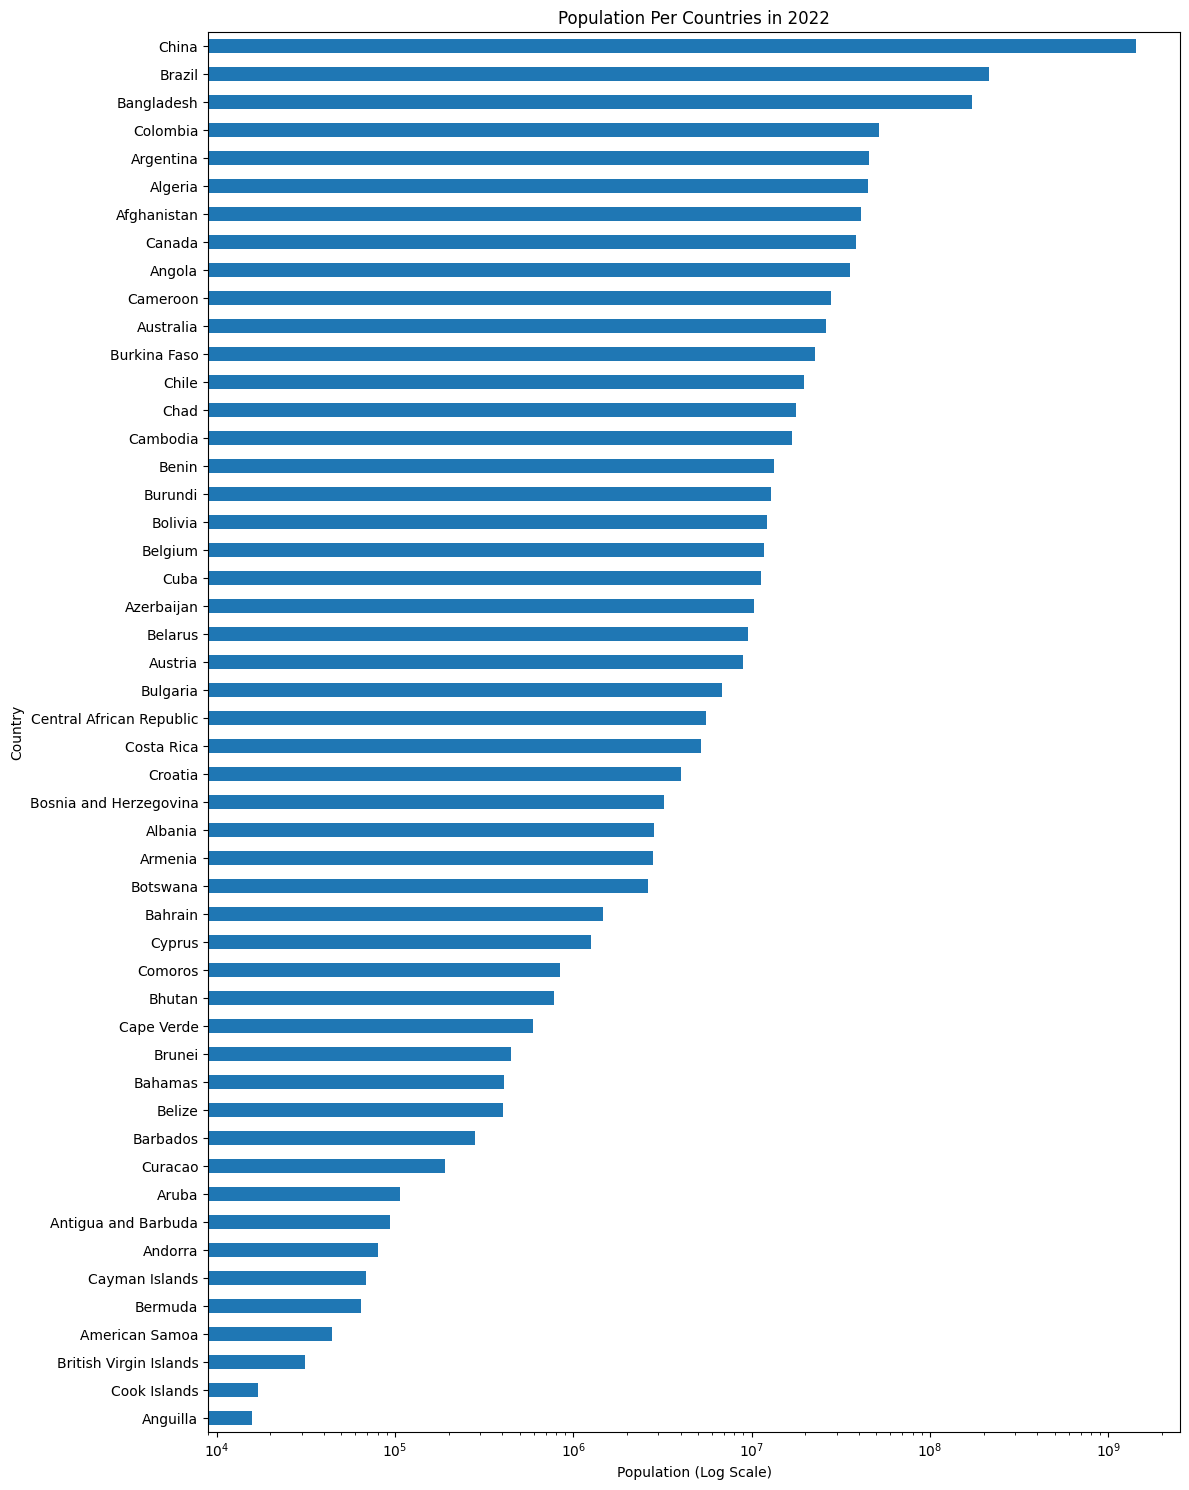

In [ ]:
fig, ax = plt.subplots(figsize=(12, 15)) # Increased height
pop_2022.sort_values(ascending=True).plot(kind='barh', ax=ax)
ax.set_title("Population Per Countries in 2022")
ax.set_xlabel("Population (Log Scale)") # Updated label for clarity
ax.set_xscale('log') # Set x-axis to logarithmic scale
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

China is the most populous country in 2022

In [ ]:
pop_1970 = df.groupby('Country')['1970 Population'].sum().sort_values(ascending=False)
print(pop_1970)

Country
China                       822534450
Brazil                       96369875
Bangladesh                   67541860
Argentina                    23842803
Canada                       21434577
Colombia                     20905254
Algeria                      13795915
Australia                    12595034
Afghanistan                  10752971
Chile                         9820481
Belgium                       9629376
Belarus                       9170786
Cuba                          8869636
Bulgaria                      8582950
Austria                       7465301
Cambodia                      6708525
Cameroon                      6452787
Angola                        6029700
Burkina Faso                  5611666
Azerbaijan                    5425317
Bolivia                       4585693
Croatia                       4492638
Bosnia and Herzegovina        3815561
Chad                          3667394
Burundi                       3497834
Benin                         3023443
Arme

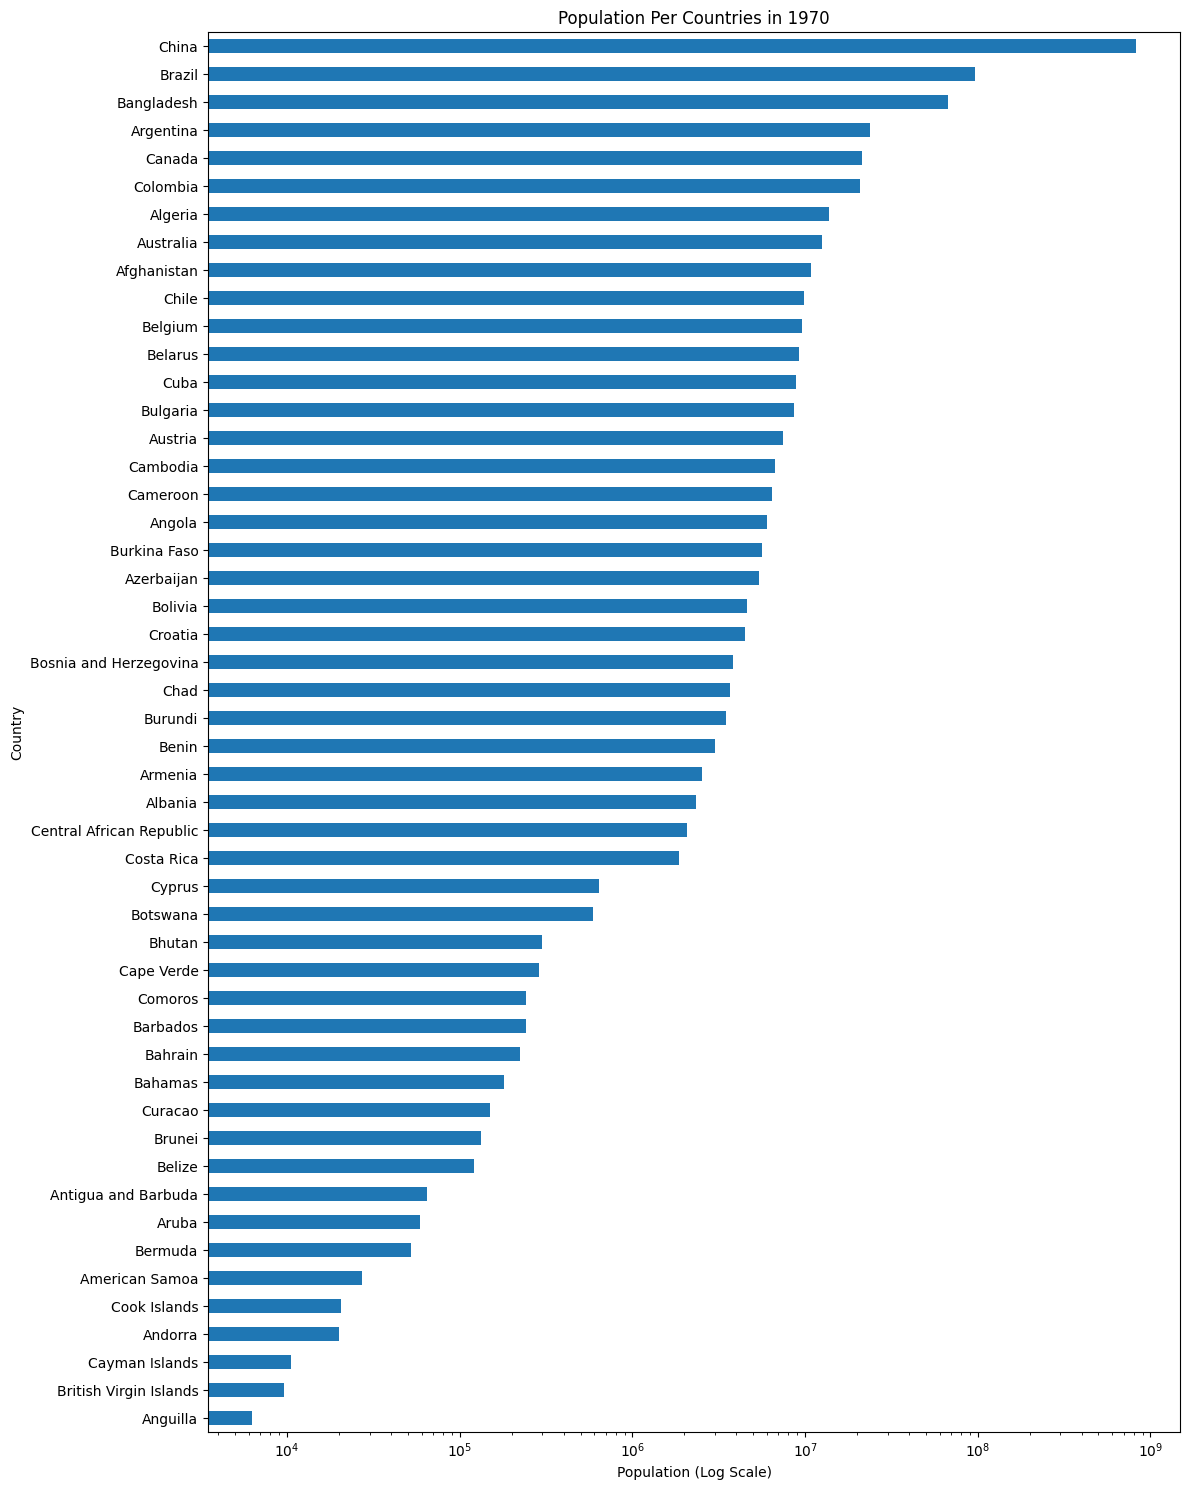

In [ ]:
fig, ax = plt.subplots(figsize=(12, 15)) # Increased height
pop_1970.sort_values(ascending=True).plot(kind='barh', ax=ax)
ax.set_title("Population Per Countries in 1970")
ax.set_xlabel("Population (Log Scale)") # Updated label for clarity
ax.set_xscale('log') # Set x-axis to logarithmic scale
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

In [ ]:
pop_2022 = df.groupby('Continent')['2022 Population'].sum().sort_values(ascending=False)
print(pop_2022)

Continent
Asia             1670812555
South America     344525683
Africa            184685628
North America      56515661
Europe             48349971
Oceania            26238697
Name: 2022 Population, dtype: int64


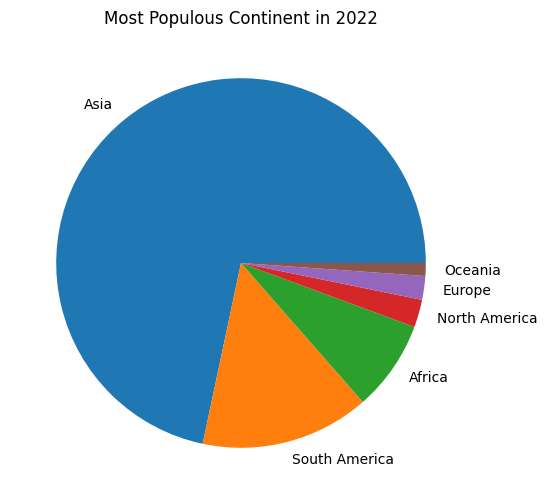

In [ ]:
pop_2022.plot(kind='pie', figsize=(10,6))
plt.title("Most Populous Continent in 2022")
plt.ylabel("")
plt.show()

In [ ]:
pop_2020 = df.groupby('Continent')['2020 Population'].sum().sort_values(ascending=False)
print(pop_2020)

Continent
Asia             1653217130
South America     340399475
Africa            175680143
North America      55960967
Europe             48679770
Oceania            25733269
Name: 2020 Population, dtype: int64


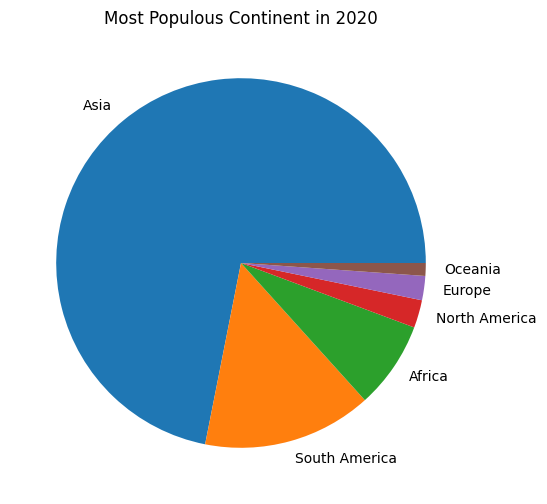

In [ ]:
pop_2020.plot(kind='pie', figsize=(10,6))
plt.title("Most Populous Continent in 2020")
plt.ylabel("")
plt.show()

In [ ]:
pop_1970 = df.groupby('Continent')['1970 Population'].sum().sort_values(ascending=False)
print(pop_1970)

Continent
Asia             916152292
South America    155524106
Europe            46142007
Africa            45267952
North America     33053764
Oceania           12642579
Name: 1970 Population, dtype: int64


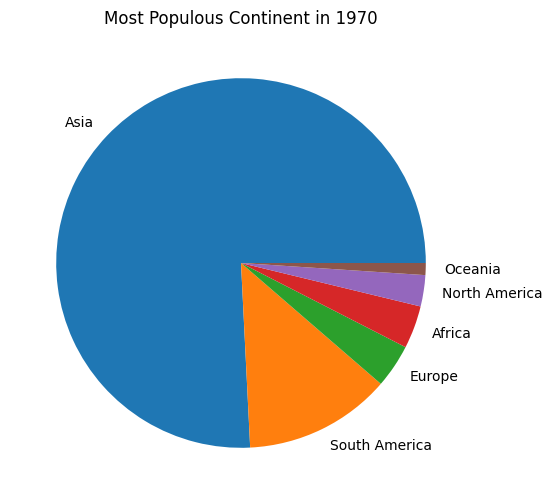

In [ ]:
pop_1970.plot(kind='pie', figsize=(10,6))
plt.title("Most Populous Continent in 1970")
plt.ylabel("")
plt.show()

In [ ]:
population_columns = ['2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population']
df['Average Population'] = df[population_columns].mean(axis=1)
avg_population_per_country = df.groupby('Country')['Average Population'].mean().sort_values(ascending=False)
print(avg_population_per_country)
avg_population_per_continent = df.groupby('Continent')['Average Population'].mean().sort_values(ascending=False)
print(avg_population_per_continent)

Country
China                       1.226929e+09
Brazil                      1.719112e+08
Bangladesh                  1.290801e+08
Argentina                   3.705995e+07
Colombia                    3.360280e+07
Algeria                     3.157280e+07
Canada                      3.129065e+07
Afghanistan                 2.444019e+07
Angola                      2.038648e+07
Australia                   2.013177e+07
Cameroon                    1.734889e+07
Chile                       1.547041e+07
Burkina Faso                1.407377e+07
Cambodia                    1.211036e+07
Cuba                        1.069430e+07
Belgium                     1.062827e+07
Chad                        1.032061e+07
Belarus                     9.784223e+06
Bolivia                     8.935532e+06
Austria                     8.194333e+06
Benin                       8.170413e+06
Burundi                     8.070710e+06
Bulgaria                    7.886460e+06
Azerbaijan                  7.110663e+06
Croatia 

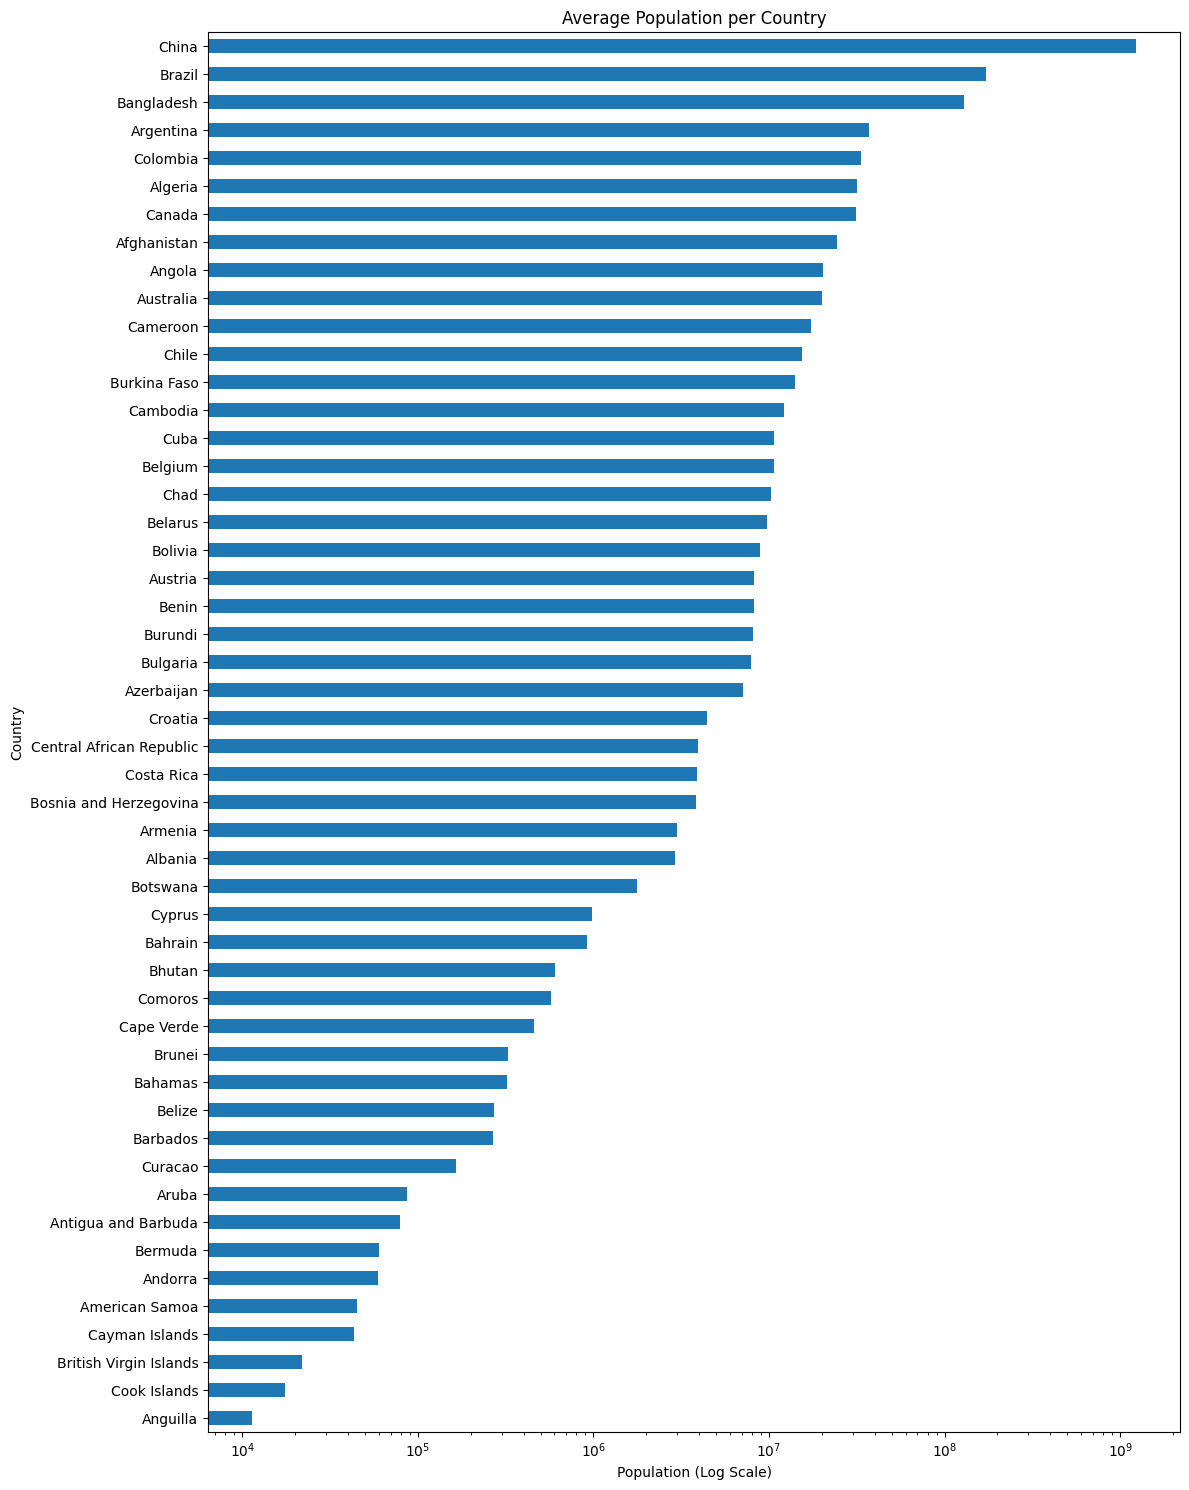

In [ ]:
fig, ax = plt.subplots(figsize=(12, 15)) # Increased height
avg_population_per_country.sort_values(ascending=True).plot(kind='barh', ax=ax)
ax.set_title("Average Population per Country")
ax.set_xlabel("Population (Log Scale)") # Updated label for clarity
ax.set_xscale('log') # Set x-axis to logarithmic scale
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

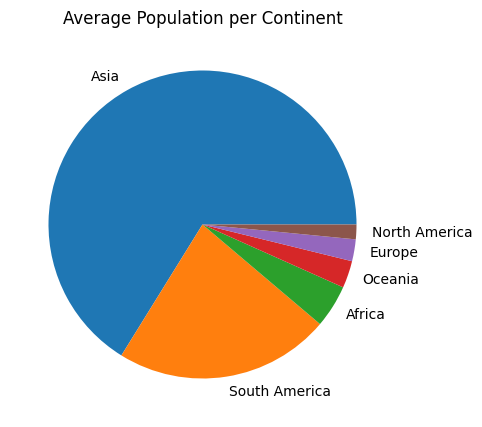

In [ ]:
avg_population_per_continent.plot(kind='pie', figsize=(8,5))
plt.title("Average Population per Continent")
plt.ylabel("")
plt.show()

## Calculate Average Population Per Year

### Subtask:
Calculate the average population across all countries for each year available in the dataset.


In [ ]:
population_columns = ['2022 Population', '2020 Population', '2015 Population', '2010 Population', '2000 Population', '1990 Population', '1980 Population', '1970 Population']
avg_population_per_year = df[population_columns].mean()
print(avg_population_per_year)

2022 Population    46622563.90
2020 Population    45993415.08
2015 Population    44407187.92
2010 Population    41484536.00
2000 Population    38638403.88
1990 Population    34369247.12
1980 Population    28988826.36
1970 Population    24175654.00
dtype: float64


## Visualize Average Population Trend

### Subtask:
Generate a line plot to visualize the calculated average population for each year, showing the trend over time.


**Reasoning**:
To prepare the data for plotting, I need to extract the year from the index of the `avg_population_per_year` Series. The current index includes ' Population', so I will remove that string and convert the result to integers to represent the years correctly.



In [ ]:
years = [int(col.replace(' Population', '')) for col in avg_population_per_year.index]
print(years)

[2022, 2020, 2015, 2010, 2000, 1990, 1980, 1970]


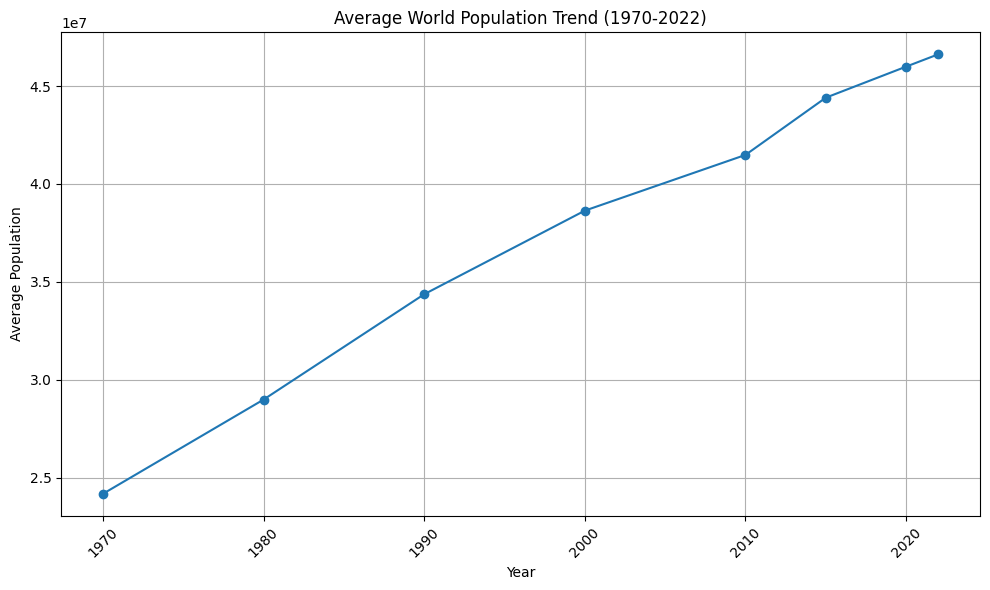

In [ ]:
# Create a Series with years as index and average population as values, then sort by year
population_trend = pd.Series(avg_population_per_year.values, index=years).sort_index()

plt.figure(figsize=(10, 6))
plt.plot(population_trend.index, population_trend.values, marker='o')
plt.title('Average World Population Trend (1970-2022)')
plt.xlabel('Year')
plt.ylabel('Average Population')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()